# 12. 能動循環の指紋 — 解離が『競合 RNA 濃度』で速くなり、やがて飽和する

> **出典**: Wagner EGH (2013) *Cycling of RNAs on Hfq.* RNA Biology 10(4):619-626.（原著の生化学: Fender et al. 2010, Genes Dev 24:2621 ほか）

11 では「能動交換で sRNA が速く乗れる」を扱った。12 はその**定量的な指紋**を見る。

- **passive**（受動）なら、滞在 RNA の解離速度は固有値——競合濃度に**無関係で一定**、そしてとても遅い（半減期 >150 分）。
- **active cycling**（能動循環）なら、**滞在 RNA の見かけ解離速度は競合 RNA 濃度とともに上がり、やがて飽和する**
  （Hfq サブユニット上の段階的な置換が律速になるため）。これが Fig.2B の形。

競合が一時的に同居する中間体を経る置換で再現する:

| 反応 | 意味 |
|---|---|
| $RH \to R + H$ | passive な自発解離（$k_i$、非常に遅い） |
| $RH + C \rightleftharpoons RHC$ | 競合 $C$ が Hfq-RH に取り付く（$k_{ass}/k_{dC}$） |
| $RHC \to CH + R$ | 段階的置換で滞在 $R$ が追い出される（$k_{rear}$、一次の律速） |

**chase 実験**: 滞在 RNA $R$ を Hfq に付けておき、t=0 で競合 $C$ を各濃度で加え、Hfq 上に残る $R$（=$RH+RHC$）の半減期を測る。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

RH, RHC, CH, Rf, C, H = (Species(x) for x in ['RH','RHC','CH','R','C','H'])
K_I, K_ASS, K_DC, K_REAR = 0.005, 0.02, 1.0, 0.5   # /min
SP = ['RH','RHC','CH','R','C','H']
def Rr(a,b,k): return ReactionRule(a,b,k)

def build():
    mdl = NetworkModel()
    for x in [Rr([RH],[Rf,H],K_I), Rr([RH,C],[RHC],K_ASS), Rr([RHC],[RH,C],K_DC), Rr([RHC],[CH,Rf],K_REAR)]:
        mdl.add_reaction_rule(x)
    return mdl

def chase(c0, t_end=300.0, ndiv=6000):
    a = run_simulation(t_end, y0={'RH':1.0,'C':float(c0)}, model=build(), solver='ode', ndiv=ndiv, species_list=SP).as_array()
    return a[:,0], a[:,1]+a[:,2]        # time, resident-on-Hfq (RH+RHC)

def halflife(c0):
    t, res = chase(c0); idx = np.where(res <= 0.5)[0]
    if len(idx) == 0: return np.nan
    i = idx[0]
    return t[0] if i == 0 else t[i-1] + (0.5-res[i-1])*(t[i]-t[i-1])/(res[i]-res[i-1])
print('ready')

ready


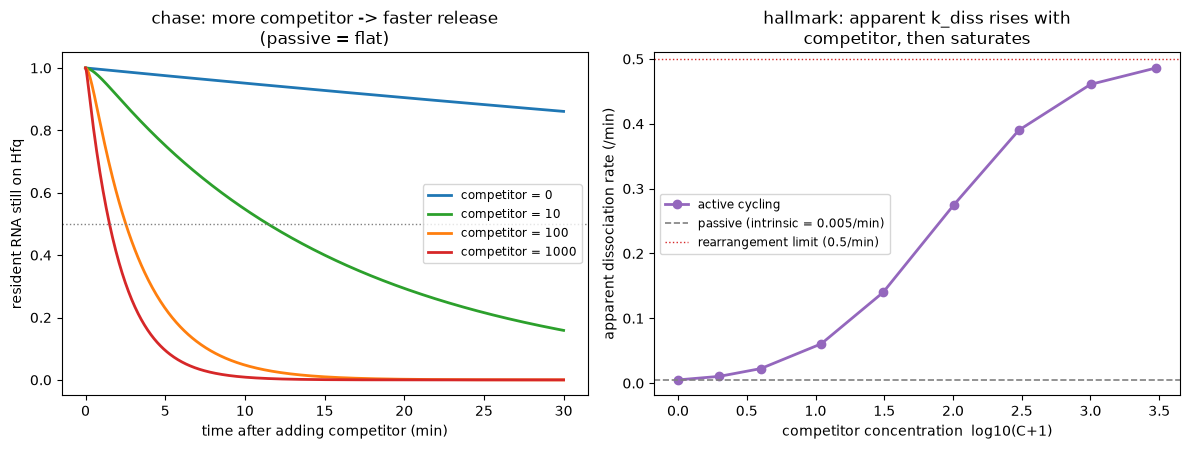

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for c0, c in [(0,'C0'), (10,'C2'), (100,'C1'), (1000,'C3')]:
    t, res = chase(c0, t_end=30.0, ndiv=600)
    ax1.plot(t, res, '-', color=c, lw=2, label=f'competitor = {c0}')
ax1.axhline(0.5, ls=':', c='gray', lw=1)
ax1.set_xlabel('time after adding competitor (min)'); ax1.set_ylabel('resident RNA still on Hfq')
ax1.set_title('chase: more competitor -> faster release\n(passive = flat)'); ax1.legend(fontsize=8.5)

c_grid = np.array([0,1,3,10,30,100,300,1000,3000], dtype=float)
kapp = np.array([np.log(2)/halflife(c) for c in c_grid])
ax2.plot(np.log10(c_grid+1), kapp, 'o-', color='C4', lw=2, label='active cycling')
ax2.axhline(K_I, ls='--', c='gray', lw=1.2, label=f'passive (intrinsic = {K_I}/min)')
ax2.axhline(K_REAR, ls=':', c='C3', lw=1, label=f'rearrangement limit ({K_REAR}/min)')
ax2.set_xlabel('competitor concentration  log10(C+1)'); ax2.set_ylabel('apparent dissociation rate (/min)')
ax2.set_title('hallmark: apparent k_diss rises with\ncompetitor, then saturates'); ax2.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 競合なし（青）だと滞在 RNA はほとんど外れない（半減期 ~140 分）。競合を増やすほど速く追い出される
  （半減期 ~140 → ~1.5 分）。**外れる速さが「相手の濃度」で決まる**のが passive と決定的に違う。
- **右**: 見かけ解離速度は、固有値（0.005/min）から立ち上がり、置換律速（$k_{rear}$=0.5/min）で**飽和**する。
  この「濃度で上がって飽和」という形（Fig.2B）が、能動循環の動かぬ指紋。

**なぜ重要か**: in vitro の K_d は「>150 分外れない」ほど強い。passive ならストレス応答に間に合わない。
だが細胞内では競合 RNA が ~100 分子いるだけで、循環は分オーダーに加速する——**強い結合と速い応答の両立**。

**11 との違い**: 11 は「新入り sRNA が速く乗れる（応答時間）」。12 は「滞在 RNA の外れる速さが競合濃度に依存し飽和する
（生化学的シグネチャ）」。同じ能動交換を、乗る側／外れる側の両面から見た。

## 発展課題（自作）

1. `K_REAR`（置換律速）を変えると、飽和値と『応答が分オーダーになる競合濃度』はどう動く？
2. 競合の強さを2種類用意し（`K_ASS` 大/小）、同じ濃度でも「良い競合者/悪い競合者」で外し方が違うことを示す（論文の IstR-1 は poor competitor）。
3. この cycling を 07 の Hfq set-point モデルに組み込むと、set-point の位置や応答は変わるか。
4. [[bio-a_hfq-phylogenetics]]: 循環は Hfq の rim / C 末端テールが担う。これらの領域の有無・配列の系統差を、
   『循環の速さ＝応答性』の違いとして解釈してみる。